# Sea Ice example notebook for 2D maps

---


The class method `plot_2d_seaice` automatically adjusts the plotting settings based on the value of the `method` argument,  
which can be either `fraction` or `thickness`, depending on what the user want to analyse and plot. The class computes the monthly climatology of the dataset over the available time period.  

When method `fraction` is selected, it is possible to set `plot_ref_contour=True` to show the contour red line where the seaice fraction equals 20%.

The `plot_type` argument determines the type of figure produced:

- `var`: For each region, plots the fraction or thickness for all requested monthly climatologies (default: March and September [3,9]) across each model or reference dataset.
- `bias`: For each of the requested months, plots the reference data, the model output, and the bias map (model – reference).

In [1]:
from aqua.diagnostics import Plot2DSeaIce, SeaIce

/home/b/b383755/miniforge3/envs/aqua-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Plot sea ice 2D maps: bias

### Plotting method: fraction

Set `method='fraction'` and `plot_type='bias'` to plot the sea ice fraction bias maps.  

As mentioned in the documentation, it is possible to provide a set of projections trough the `projkw` dictionary as in the example below (check documentation for 
all the available projections).  

In [2]:
method = "fraction"  # This is the method we want to compute with the seaice data
varname = "siconc"  # This is the right variable name relative to the desired method for IFS-NEMO
source = "lra-r100-monthly"  # source name can change depending on the model and exp
regions_domain = ["arctic", "antarctic"]
regrid = "r100"
loglevel = "info"

# Model data
seaice_model = SeaIce(
    model="IFS-NEMO",
    exp="historical-1990",
    source=source,
    regions=regions_domain,
    startdate="1991-01-01",
    enddate="2000-01-01",
    regrid=regrid,
    loglevel="info",
)
simod = seaice_model.compute_seaice(method=method, var=varname)

# Reference data
seaice_ref_nh = SeaIce(
    model="OSI-SAF",
    exp="osi-saf-aqua",
    source="nh-monthly",
    regions="arctic",
    startdate="1991-01-01",
    enddate="2000-01-01",
    regrid=regrid,
    loglevel=loglevel,
)
si_ref_nh = seaice_ref_nh.compute_seaice(method=method, var=varname)

seaice_ref_sh = SeaIce(
    model="OSI-SAF",
    exp="osi-saf-aqua",
    source="sh-monthly",
    regions="antarctic",
    startdate="1991-01-01",
    enddate="2000-01-01",
    regrid=regrid,
    loglevel=loglevel,
)
si_ref_sh = seaice_ref_sh.compute_seaice(method=method, var=varname)

2026-03-17 11:27:38 :: ConfigPath :: INFO     -> IFS-NEMO_historical-1990_lra-r100-monthly triplet found in in climatedt-o25.1!
2026-03-17 11:27:38 :: ConfigPath :: INFO     -> IFS-NEMO_historical-1990_lra-r100-monthly triplet found in in climatedt-phase1!
2026-03-17 11:27:38 :: ConfigPath :: WARNING  -> Multiple triplets found in ['climatedt-o25.1', 'climatedt-phase1'], setting climatedt-o25.1 as the default
2026-03-17 11:27:39 :: Reader :: WARNING  -> The machine configured (levante) is different from the machine in the catalog (mn5). Please check that the data you are looking for are on the machine you are working on.
2026-03-17 11:27:39 :: FixerConfigure :: INFO     -> Convention dictionary: eccodes-2.39.0
2026-03-17 11:27:39 :: FixerConfigure :: INFO     -> No fixer_name found, only convention will be applied
2026-03-17 11:27:39 :: Reader :: INFO     -> Grid metadata is lon-lat-r100
2026-03-17 11:27:39 :: Regridder :: INFO     -> Grid name: lon-lat-r100
2026-03-17 11:27:39 :: Regr

2026-03-17 11:28:04 :: Plot2DSeaIce :: INFO     -> Starting Plot2DSeaIce run
2026-03-17 11:28:04 :: Plot2DSeaIce :: INFO     -> Plotting region: Arctic
2026-03-17 11:28:07 :: create_folder :: INFO     -> Folder ./png already exists
2026-03-17 11:28:13 :: OutputSaver :: INFO     -> Saved PNG: ./png/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.OSI-SAF.osi-saf-aqua.fraction.arctic.png
2026-03-17 11:28:13 :: create_folder :: INFO     -> Folder ./pdf already exists
2026-03-17 11:28:25 :: OutputSaver :: INFO     -> Saved PDF: ./pdf/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.OSI-SAF.osi-saf-aqua.fraction.arctic.pdf
2026-03-17 11:28:25 :: create_folder :: INFO     -> Folder ./svg already exists
2026-03-17 11:29:30 :: OutputSaver :: INFO     -> Saved SVG: ./svg/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.OSI-SAF.osi-saf-aqua.fraction.arctic.svg


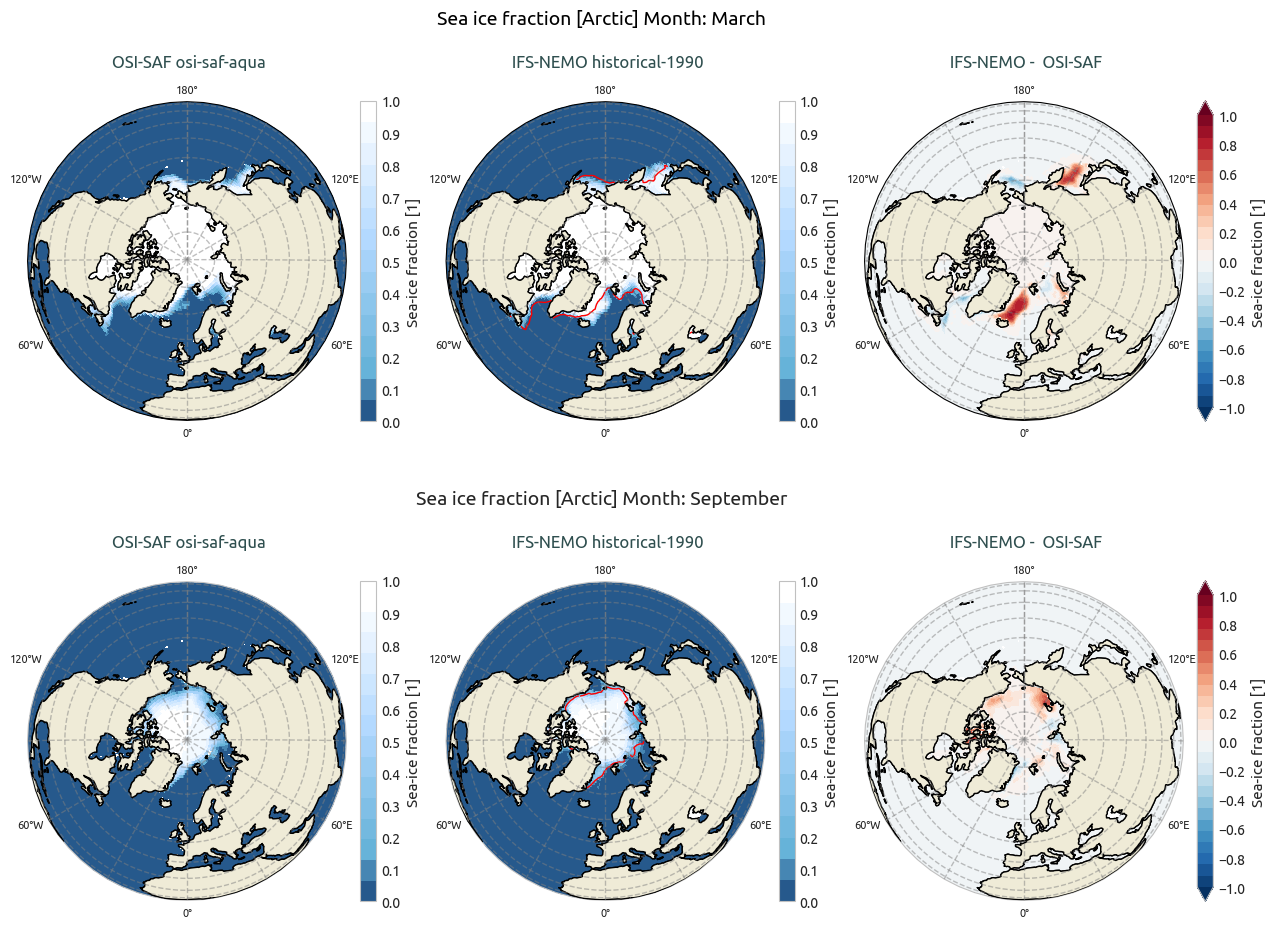

2026-03-17 11:29:34 :: Plot2DSeaIce :: INFO     -> Plotting region: Antarctic
2026-03-17 11:29:38 :: create_folder :: INFO     -> Folder ./png already exists
2026-03-17 11:29:43 :: OutputSaver :: INFO     -> Saved PNG: ./png/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.OSI-SAF.osi-saf-aqua.fraction.antarctic.png
2026-03-17 11:29:43 :: create_folder :: INFO     -> Folder ./pdf already exists
2026-03-17 11:29:54 :: OutputSaver :: INFO     -> Saved PDF: ./pdf/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.OSI-SAF.osi-saf-aqua.fraction.antarctic.pdf
2026-03-17 11:29:54 :: create_folder :: INFO     -> Folder ./svg already exists
2026-03-17 11:30:59 :: OutputSaver :: INFO     -> Saved SVG: ./svg/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.OSI-SAF.osi-saf-aqua.fraction.antarctic.svg


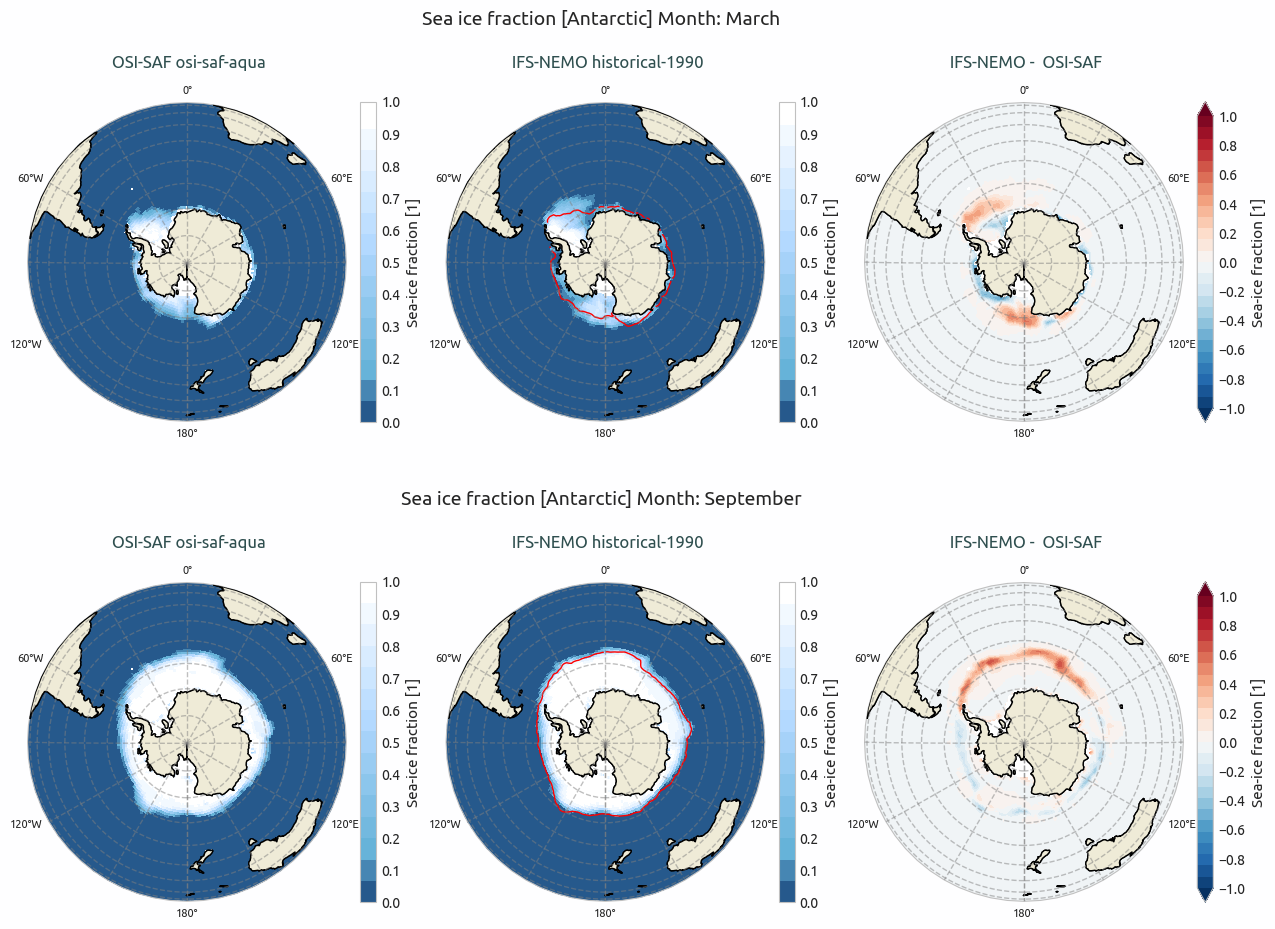

In [3]:
p2dsi = Plot2DSeaIce(models=simod, ref=[si_ref_sh, si_ref_nh], loglevel="info")

p2dsi.plot_2d_seaice(
    plot_type="bias",
    method="fraction",
    projkw={"projpars": {"central_longitude": 0.0, "central_latitude": "max_lat_signed"}, "projname": "orthographic"},
    plot_ref_contour=True,
    save_format=["png", "pdf", "svg"],
    show=True,
)

#### Customised projections

In `projkw`, it is possible to set the lat-lon boundaries of the plotted regions, allowing for a refined 'zoom' of the desired area using the `extent_regions` parameter.

2026-03-17 11:31:47 :: Plot2DSeaIce :: INFO     -> Starting Plot2DSeaIce run
2026-03-17 11:31:47 :: Plot2DSeaIce :: INFO     -> Plotting region: Arctic
2026-03-17 11:31:52 :: create_folder :: INFO     -> Folder ./png already exists
2026-03-17 11:32:00 :: OutputSaver :: INFO     -> Saved PNG: ./png/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.OSI-SAF.osi-saf-aqua.fraction.arctic.png
2026-03-17 11:32:00 :: create_folder :: INFO     -> Folder ./pdf already exists
2026-03-17 11:32:13 :: OutputSaver :: INFO     -> Saved PDF: ./pdf/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.OSI-SAF.osi-saf-aqua.fraction.arctic.pdf
2026-03-17 11:32:13 :: create_folder :: INFO     -> Folder ./svg already exists
2026-03-17 11:33:06 :: OutputSaver :: INFO     -> Saved SVG: ./svg/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.OSI-SAF.osi-saf-aqua.fraction.arctic.svg


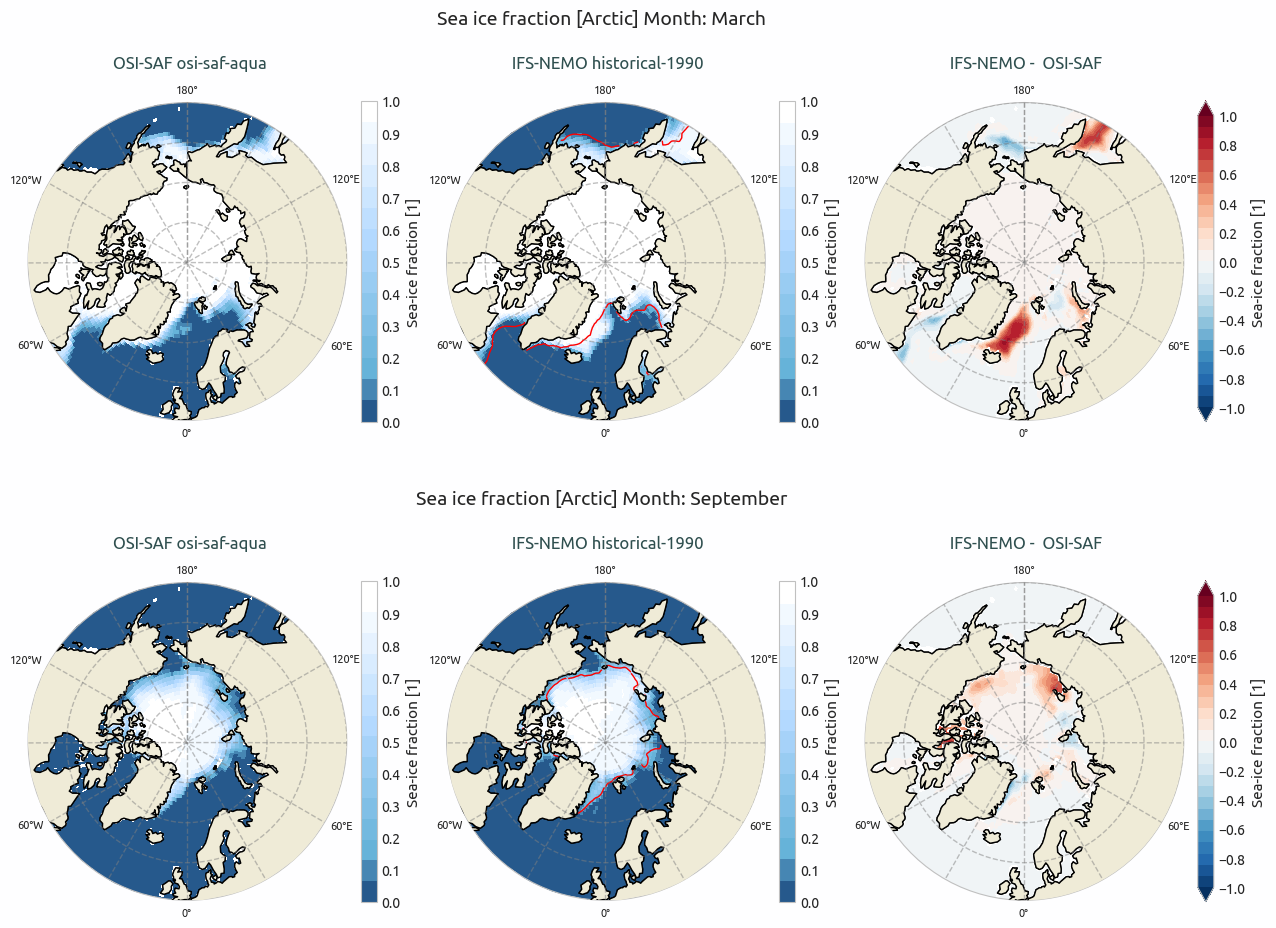

2026-03-17 11:33:12 :: Plot2DSeaIce :: INFO     -> Plotting region: Antarctic
2026-03-17 11:33:17 :: create_folder :: INFO     -> Folder ./png already exists
2026-03-17 11:33:25 :: OutputSaver :: INFO     -> Saved PNG: ./png/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.OSI-SAF.osi-saf-aqua.fraction.antarctic.png
2026-03-17 11:33:25 :: create_folder :: INFO     -> Folder ./pdf already exists
2026-03-17 11:33:38 :: OutputSaver :: INFO     -> Saved PDF: ./pdf/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.OSI-SAF.osi-saf-aqua.fraction.antarctic.pdf
2026-03-17 11:33:38 :: create_folder :: INFO     -> Folder ./svg already exists
2026-03-17 11:34:30 :: OutputSaver :: INFO     -> Saved SVG: ./svg/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.OSI-SAF.osi-saf-aqua.fraction.antarctic.svg


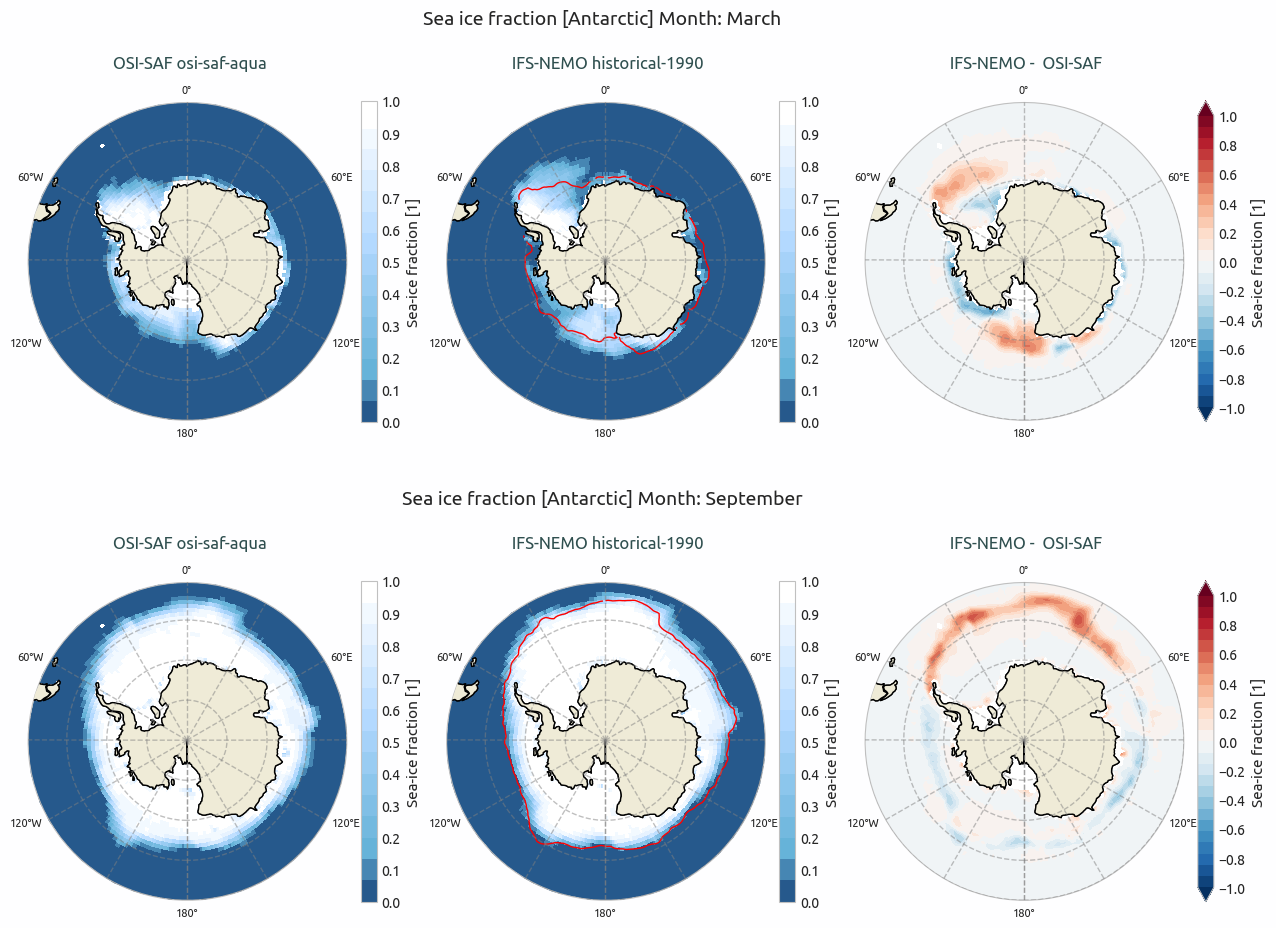

In [4]:
p2dsi = Plot2DSeaIce(models=simod, ref=[si_ref_sh, si_ref_nh], loglevel="info")

p2dsi.plot_2d_seaice(
    plot_type="bias",
    method="fraction",
    projkw={
        "projpars": {"central_longitude": 0.0, "central_latitude": "max_lat_signed"},
        "extent_regions": {"Arctic": [-180, 180, 50, 90], "Antarctic": [-180, 180, -50, -90]},
        "projname": "azimuthal_equidistant",
    },
    plot_ref_contour=True,
    save_format=["png", "pdf", "svg"],
    show=True,
)

### Plotting method: thickness

Set `method='thickness'` to plot the sea ice thickness and the bias maps.

In [5]:
method = "thickness"  # This is the method we want to compute with the seaice data
varname = "sithick"  # This is the right variable name relative to the desired method for IFS-NEMO
source = "lra-r100-monthly"  # source name can change depending on the model and exp
regions_domain = ["arctic", "antarctic"]
regrid = "r100"
loglevel = "info"

# Model data
seaice_model = SeaIce(
    model="IFS-NEMO",
    exp="historical-1990",
    source=source,
    regions=regions_domain,
    startdate="1991-01-01",
    enddate="2000-01-01",
    regrid=regrid,
    loglevel="info",
)
simod = seaice_model.compute_seaice(method=method, var=varname)


# Reference data
varn = "sithick"

seaice_ref_nh = SeaIce(
    model="PSC",
    exp="PIOMAS",
    source="monthly",
    regions="arctic",
    startdate="1991-01-01",
    enddate="2000-01-01",
    regrid=regrid,
    loglevel=loglevel,
)
si_ref_nh = seaice_ref_nh.compute_seaice(method=method, var=varn)

seaice_ref_sh = SeaIce(
    model="PSC",
    exp="GIOMAS",
    source="monthly",
    regions="antarctic",
    startdate="1991-01-01",
    enddate="2000-01-01",
    regrid=regrid,
    loglevel=loglevel,
)
si_ref_sh = seaice_ref_sh.compute_seaice(method=method, var=varn)

2026-03-17 11:34:44 :: ConfigPath :: INFO     -> IFS-NEMO_historical-1990_lra-r100-monthly triplet found in in climatedt-o25.1!
2026-03-17 11:34:44 :: ConfigPath :: INFO     -> IFS-NEMO_historical-1990_lra-r100-monthly triplet found in in climatedt-phase1!
2026-03-17 11:34:44 :: ConfigPath :: WARNING  -> Multiple triplets found in ['climatedt-o25.1', 'climatedt-phase1'], setting climatedt-o25.1 as the default
2026-03-17 11:34:44 :: Reader :: WARNING  -> The machine configured (levante) is different from the machine in the catalog (mn5). Please check that the data you are looking for are on the machine you are working on.
2026-03-17 11:34:45 :: FixerConfigure :: INFO     -> Convention dictionary: eccodes-2.39.0
2026-03-17 11:34:45 :: FixerConfigure :: INFO     -> No fixer_name found, only convention will be applied
2026-03-17 11:34:45 :: Reader :: INFO     -> Grid metadata is lon-lat-r100
2026-03-17 11:34:45 :: Regridder :: INFO     -> Grid name: lon-lat-r100
2026-03-17 11:34:45 :: Regr

2026-03-17 11:35:10 :: Plot2DSeaIce :: INFO     -> Starting Plot2DSeaIce run
2026-03-17 11:35:10 :: Plot2DSeaIce :: INFO     -> Plotting region: Arctic
2026-03-17 11:35:15 :: create_folder :: INFO     -> Folder ./png already exists
2026-03-17 11:35:22 :: OutputSaver :: INFO     -> Saved PNG: ./png/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.PSC.PIOMAS.thickness.arctic.png
2026-03-17 11:35:22 :: create_folder :: INFO     -> Folder ./pdf already exists
2026-03-17 11:35:35 :: OutputSaver :: INFO     -> Saved PDF: ./pdf/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.PSC.PIOMAS.thickness.arctic.pdf
2026-03-17 11:35:35 :: create_folder :: INFO     -> Folder ./svg already exists
2026-03-17 11:36:25 :: OutputSaver :: INFO     -> Saved SVG: ./svg/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.PSC.PIOMAS.thickness.arctic.svg


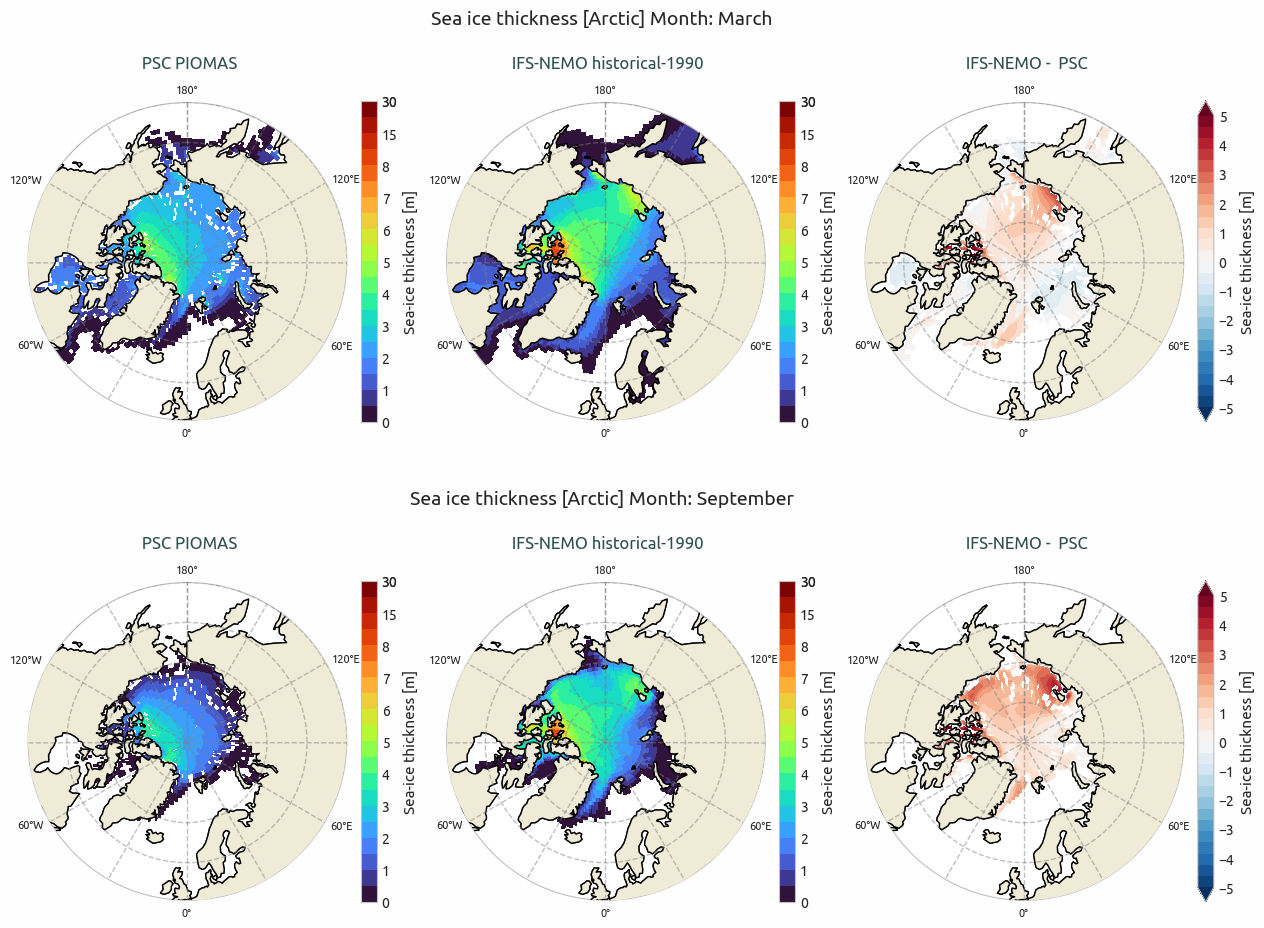

2026-03-17 11:36:31 :: Plot2DSeaIce :: INFO     -> Plotting region: Antarctic
2026-03-17 11:36:35 :: create_folder :: INFO     -> Folder ./png already exists
2026-03-17 11:36:43 :: OutputSaver :: INFO     -> Saved PNG: ./png/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.PSC.GIOMAS.thickness.antarctic.png
2026-03-17 11:36:43 :: create_folder :: INFO     -> Folder ./pdf already exists
2026-03-17 11:36:55 :: OutputSaver :: INFO     -> Saved PDF: ./pdf/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.PSC.GIOMAS.thickness.antarctic.pdf
2026-03-17 11:36:55 :: create_folder :: INFO     -> Folder ./svg already exists
2026-03-17 11:37:45 :: OutputSaver :: INFO     -> Saved SVG: ./svg/seaice.bias.climatedt-o25_1.IFS-NEMO.historical-1990.r1.PSC.GIOMAS.thickness.antarctic.svg


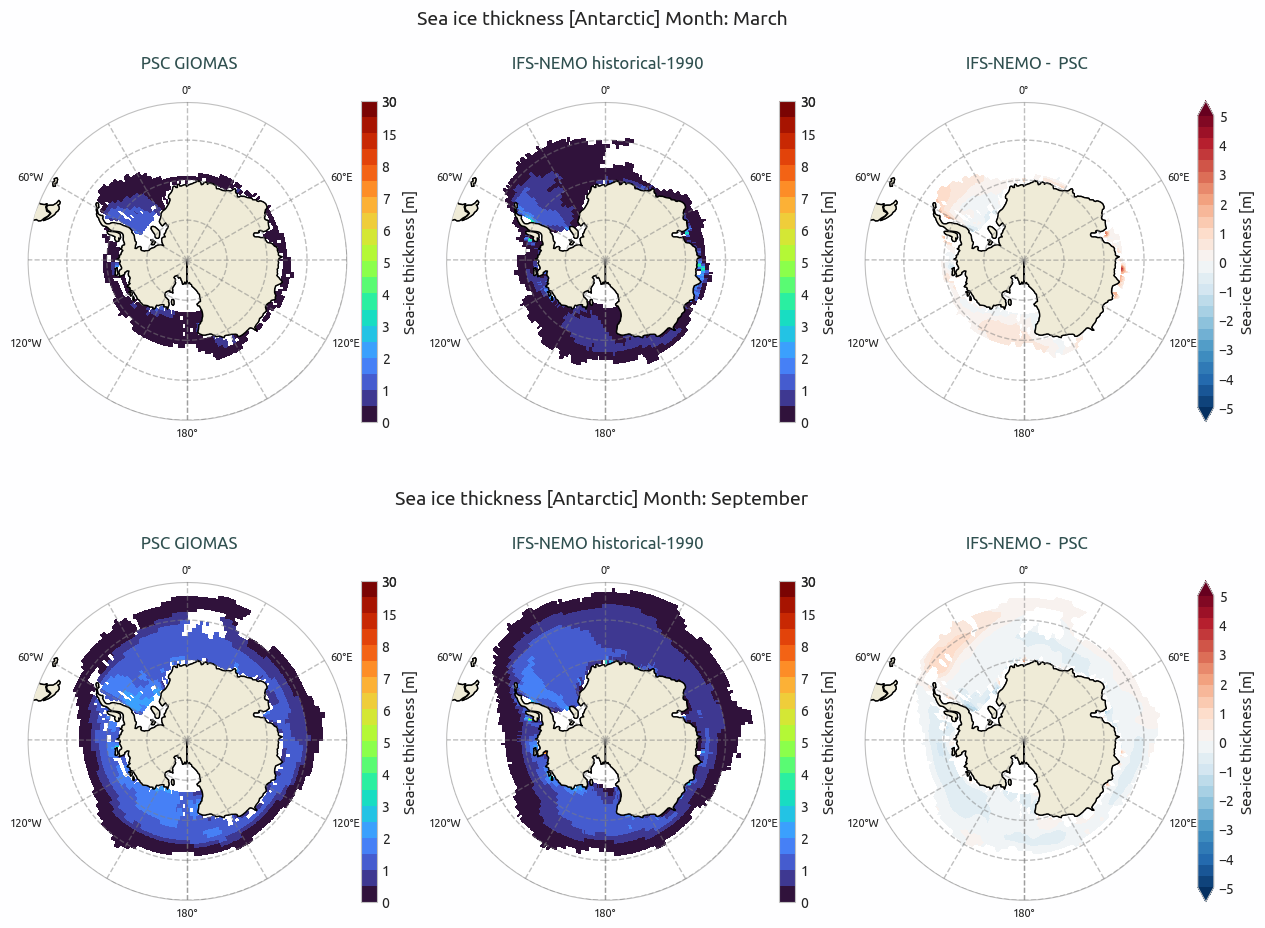

In [6]:
p2dsi = Plot2DSeaIce(models=simod, ref=[si_ref_sh, si_ref_nh], loglevel="info")
p2dsi.plot_2d_seaice(
    plot_type="bias",
    method="thickness",
    projkw={
        "projpars": {"central_longitude": 0.0, "central_latitude": "max_lat_signed"},
        "extent_regions": {"Arctic": [-180, 180, 50, 90], "Antarctic": [-180, 180, -50, -90]},
        "projname": "azimuthal_equidistant",
    },
    save_format=["png", "pdf", "svg"],
    show=True,
)

## Plot sea ice 2D maps: var

Setting `plot_type='var'` will produce plot without the bias maps, with the aim to highlight the variability across the  
months of the year for each model/reference in each region.

In this example `months=[6,12]` (June, December) allow to choose the monthly climatologies for each model/reference to be plotted. 

2025-09-23 15:41:33 :: Plot2DSeaIce :: INFO     -> Starting Plot2DSeaIce run
2025-09-23 15:41:33 :: Plot2DSeaIce :: INFO     -> Plotting region: Arctic
2025-09-23 15:41:33 :: Plot2DSeaIce :: INFO     -> Processing reference data: sea_ice_fraction_arctic
2025-09-23 15:41:37 :: Plot2DSeaIce :: INFO     -> Processing model data: sea_ice_fraction_arctic
2025-09-23 15:41:42 :: Plot2DSeaIce :: INFO     -> Plotting region: Antarctic
2025-09-23 15:41:42 :: Plot2DSeaIce :: INFO     -> Processing reference data: sea_ice_fraction_antarctic
2025-09-23 15:41:45 :: Plot2DSeaIce :: INFO     -> Processing model data: sea_ice_fraction_antarctic


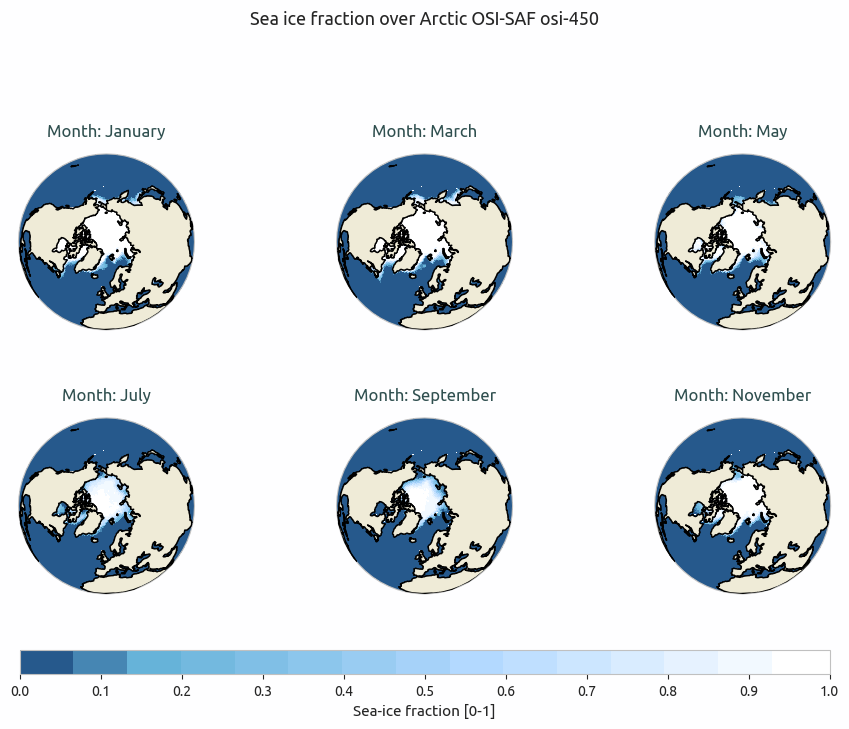

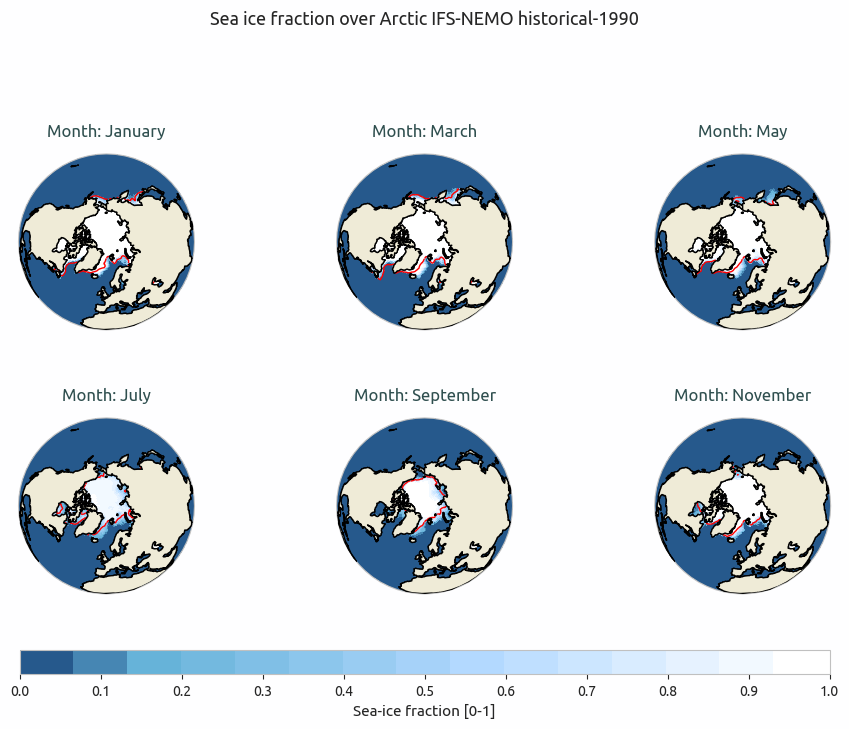

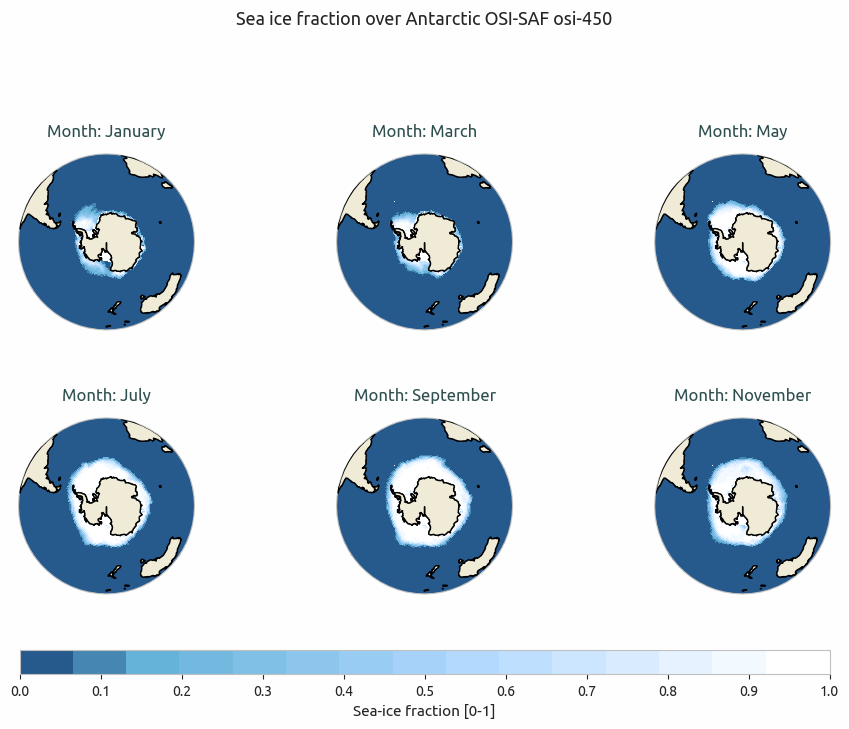

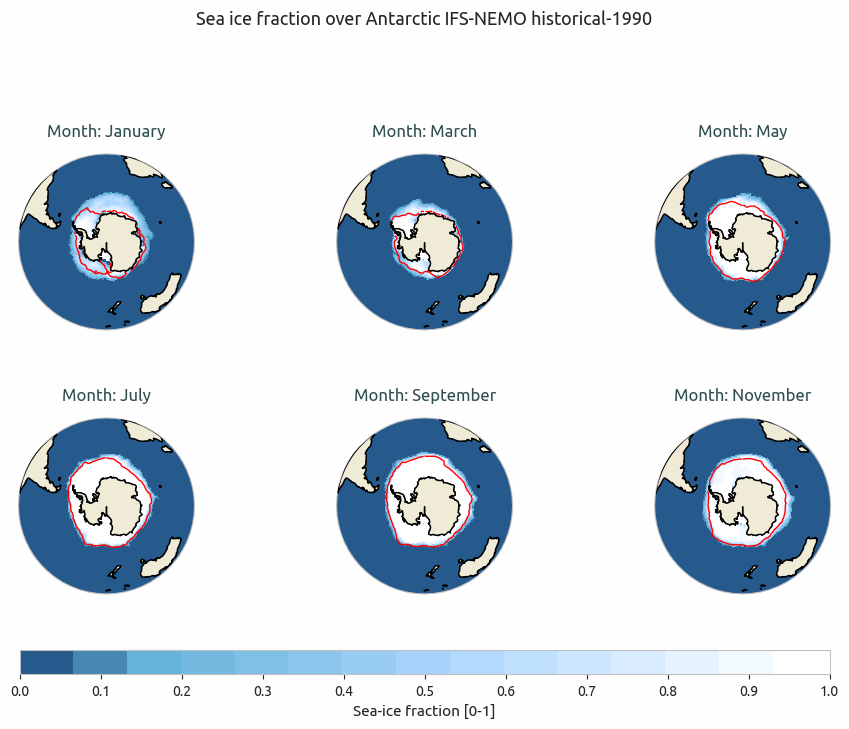

In [9]:
p2dsi = Plot2DSeaIce(models=simod, ref=[si_ref_sh, si_ref_nh], loglevel="info")

p2dsi.plot_2d_seaice(
    plot_type="var",
    method="fraction",
    projkw={"projname": "orthographic", "projpars": {"central_longitude": 0.0, "central_latitude": "max_lat_signed"}},
    months=[1, 3, 5, 7, 9, 11],
    plot_ref_contour=True,
    save_pdf=False,
    save_png=False,
)